In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("./data/KOBIS_역대_박스오피스.csv", encoding="utf-8")
df.head()

,순위,영화명,개봉일,매출액,관객수,스크린수,대표국적,국적,배급사
0,1,명량,2014-07-30,1.357484e+11,17613682,1587,한국,한국,(주)씨제이이엔엠
1,2,극한직업,2019-01-23,1.396480e+11,16264944,1978,한국,한국,(주)씨제이이엔엠
2,3,신과함께-죄와 벌,2017-12-20,1.156987e+11,14410754,1912,한국,한국,롯데쇼핑㈜롯데엔터테인먼트
3,4,국제시장,2014-12-17,1.109135e+11,14257115,966,한국,한국,(주)씨제이이엔엠
4,5,베테랑,2015-08-05,1.051682e+11,13414009,1064,한국,한국,(주)씨제이이엔엠


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   순위      500 non-null    int64  
 1   영화명     500 non-null    str    
 2   개봉일     500 non-null    str    
 3   매출액     490 non-null    float64
 4   관객수     500 non-null    int64  
 5   스크린수    500 non-null    int64  
 6   대표국적    500 non-null    str    
 7   국적      500 non-null    str    
 8   배급사     496 non-null    str    
dtypes: float64(1), int64(3), str(5)
memory usage: 35.3 KB


In [3]:
df2 = df.copy()
df2.isnull().sum()

순위       0
영화명      0
개봉일      0
매출액     10
관객수      0
스크린수     0
대표국적     0
국적       0
배급사      4
dtype: int64

In [4]:
null_rate = df2['매출액'].isnull().sum() / df2['매출액'].shape[0]*100

In [5]:
null_rate

np.float64(2.0)

In [6]:
df2

,순위,영화명,개봉일,매출액,관객수,스크린수,대표국적,국적,배급사
0,1,명량,2014-07-30,1.357484e+11,17613682,1587,한국,한국,(주)씨제이이엔엠
1,2,극한직업,2019-01-23,1.396480e+11,16264944,1978,한국,한국,(주)씨제이이엔엠
2,3,신과함께-죄와 벌,2017-12-20,1.156987e+11,14410754,1912,한국,한국,롯데쇼핑㈜롯데엔터테인먼트
3,4,국제시장,2014-12-17,1.109135e+11,14257115,966,한국,한국,(주)씨제이이엔엠
4,5,베테랑,2015-08-05,1.051682e+11,13414009,1064,한국,한국,(주)씨제이이엔엠
...,...,...,...,...,...,...,...,...,...
495,496,비공식작전,2023-08-02,1.019214e+10,1058645,1151,한국,한국,(주)쇼박스
496,497,남극일기,2005-05-19,0.000000e+00,1057311,78,한국,한국,(주)쇼박스
497,498,동창생,2013-11-06,7.010197e+09,1048280,660,한국,한국,(주)쇼박스
498,499,시크릿,2009-12-03,7.979592e+09,1046787,397,한국,한국,씨제이엔터테인먼트


In [7]:
df2.drop(['대표국적'], axis=1, inplace=True)

In [8]:
df2

,순위,영화명,개봉일,매출액,관객수,스크린수,국적,배급사
0,1,명량,2014-07-30,1.357484e+11,17613682,1587,한국,(주)씨제이이엔엠
1,2,극한직업,2019-01-23,1.396480e+11,16264944,1978,한국,(주)씨제이이엔엠
2,3,신과함께-죄와 벌,2017-12-20,1.156987e+11,14410754,1912,한국,롯데쇼핑㈜롯데엔터테인먼트
3,4,국제시장,2014-12-17,1.109135e+11,14257115,966,한국,(주)씨제이이엔엠
4,5,베테랑,2015-08-05,1.051682e+11,13414009,1064,한국,(주)씨제이이엔엠
...,...,...,...,...,...,...,...,...
495,496,비공식작전,2023-08-02,1.019214e+10,1058645,1151,한국,(주)쇼박스
496,497,남극일기,2005-05-19,0.000000e+00,1057311,78,한국,(주)쇼박스
497,498,동창생,2013-11-06,7.010197e+09,1048280,660,한국,(주)쇼박스
498,499,시크릿,2009-12-03,7.979592e+09,1046787,397,한국,씨제이엔터테인먼트


In [9]:
df2 = df.copy()

In [10]:
df2.dropna(subset=['배급사'],inplace=True)
df2.isnull().sum()

순위       0
영화명      0
개봉일      0
매출액     10
관객수      0
스크린수     0
대표국적     0
국적       0
배급사      0
dtype: int64

In [11]:
df2['매출액'].fillna(0, inplace=True)
df2.isnull().sum()

/tmp/ipykernel_11629/1019775179.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df2['매출액'].fillna(0, inplace=True)


순위       0
영화명      0
개봉일      0
매출액     10
관객수      0
스크린수     0
대표국적     0
국적       0
배급사      0
dtype: int64

In [12]:
product = df2.groupby(['배급사']).sum()

In [13]:
product.sort_values(by = '스크린수', ascending=False).head()

,순위,영화명,개봉일,매출액,관객수,스크린수,대표국적,국적
배급사,,,,,,,,
(주)씨제이이엔엠,18682,"명량극한직업국제시장베테랑광해, 왕이 된 남자기생충엑시트설국열차수상한 그녀공조히말라야...",2014-07-302019-01-232014-12-172015-08-052012-0...,2.797282e+12,357136172,88373,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,"한국한국한국한국한국한국한국한국,체코한국한국한국한국한국한국한국,독일한국한국한국한국한국..."
(주)쇼박스,19672,괴물도둑들암살택시운전사파묘검사외전관상국가대표디워웰컴 투 동막골터널내부자들럭키은밀하게...,2006-07-272012-07-252015-07-222017-08-022024-0...,1.903165e+12,335279803,61542,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,"한국한국,홍콩한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한..."
(주)넥스트엔터테인먼트월드(NEW),12793,7번방의 선물부산행변호인연평해전숨바꼭질감시자들안시성더 킹밀수독전바람과 함께 사라지다...,2013-01-232016-07-202013-12-182015-06-242013-0...,1.361361e+12,172061923,51181,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...
롯데컬처웍스(주)롯데엔터테인먼트,4247,신과함께-인과 연한산: 용의 출현완벽한 타인파일럿콘크리트 유토피아82년생 김지영모가...,2018-08-012022-07-272018-10-312024-07-312023-0...,5.623134e+11,63587646,29894,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국
롯데쇼핑㈜롯데엔터테인먼트,11283,신과함께-죄와 벌해적: 바다로 간 산적과속스캔들최종병기 활청년경찰덕혜옹주더 테러 라...,2017-12-202014-08-062008-12-032011-08-102017-0...,8.890049e+11,129180401,25050,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...


In [14]:
screen = product.query('스크린수 > = 30000') # screen = product[product['스크린수'] >= 30000]
screen

,순위,영화명,개봉일,매출액,관객수,스크린수,대표국적,국적
배급사,,,,,,,,
(주)넥스트엔터테인먼트월드(NEW),12793,7번방의 선물부산행변호인연평해전숨바꼭질감시자들안시성더 킹밀수독전바람과 함께 사라지다...,2013-01-232016-07-202013-12-182015-06-242013-0...,1.361361e+12,172061923,51181,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...
(주)쇼박스,19672,괴물도둑들암살택시운전사파묘검사외전관상국가대표디워웰컴 투 동막골터널내부자들럭키은밀하게...,2006-07-272012-07-252015-07-222017-08-022024-0...,1.903165e+12,335279803,61542,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,"한국한국,홍콩한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한..."
(주)씨제이이엔엠,18682,"명량극한직업국제시장베테랑광해, 왕이 된 남자기생충엑시트설국열차수상한 그녀공조히말라야...",2014-07-302019-01-232014-12-172015-08-052012-0...,2.797282e+12,357136172,88373,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,"한국한국한국한국한국한국한국한국,체코한국한국한국한국한국한국한국,독일한국한국한국한국한국..."


In [15]:
a = product.sort_values(by="관객수", ascending=False).head()
a

,순위,영화명,개봉일,매출액,관객수,스크린수,대표국적,국적
배급사,,,,,,,,
(주)씨제이이엔엠,18682,"명량극한직업국제시장베테랑광해, 왕이 된 남자기생충엑시트설국열차수상한 그녀공조히말라야...",2014-07-302019-01-232014-12-172015-08-052012-0...,2.797282e+12,357136172,88373,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,"한국한국한국한국한국한국한국한국,체코한국한국한국한국한국한국한국,독일한국한국한국한국한국..."
(주)쇼박스,19672,괴물도둑들암살택시운전사파묘검사외전관상국가대표디워웰컴 투 동막골터널내부자들럭키은밀하게...,2006-07-272012-07-252015-07-222017-08-022024-0...,1.903165e+12,335279803,61542,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,"한국한국,홍콩한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한..."
씨제이엔터테인먼트,16483,"해운대화려한 휴가타짜좋은 놈, 나쁜 놈, 이상한 놈아저씨전우치투사부일체살인의 추억동...",2009-07-222007-07-252006-09-282008-07-172010-0...,5.246996e+11,185843562,15179,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...
(주)넥스트엔터테인먼트월드(NEW),12793,7번방의 선물부산행변호인연평해전숨바꼭질감시자들안시성더 킹밀수독전바람과 함께 사라지다...,2013-01-232016-07-202013-12-182015-06-242013-0...,1.361361e+12,172061923,51181,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...
롯데쇼핑㈜롯데엔터테인먼트,11283,신과함께-죄와 벌해적: 바다로 간 산적과속스캔들최종병기 활청년경찰덕혜옹주더 테러 라...,2017-12-202014-08-062008-12-032011-08-102017-0...,8.890049e+11,129180401,25050,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...


In [16]:
df2['스크린수_cut'] = pd.cut(df2['스크린수'], bins= 10)
df2['스크린수_cut'].value_counts()

스크린수_cut
(-2.98, 298.0]      141
(298.0, 596.0]       94
(596.0, 894.0]       94
(894.0, 1192.0]      72
(1192.0, 1490.0]     45
(1490.0, 1788.0]     23
(1788.0, 2086.0]     14
(2086.0, 2384.0]      7
(2384.0, 2682.0]      4
(2682.0, 2980.0]      2
Name: count, dtype: int64

In [17]:
df2['스크린수_cut'] = pd.qcut(df2['스크린수'], q = 20)
df2['스크린수_cut'].value_counts()

스크린수_cut
(-0.001, 45.0]       26
(45.0, 55.0]         26
(70.0, 82.0]         25
(104.0, 350.5]       25
(350.5, 448.0]       25
(448.0, 512.0]       25
(566.0, 620.0]       25
(620.0, 691.25]      25
(691.25, 785.0]      25
(785.0, 884.0]       25
(974.0, 1075.75]     25
(1075.75, 1176.0]    25
(1296.75, 1493.5]    25
(1493.5, 1821.5]     25
(1821.5, 2980.0]     25
(55.0, 70.0]         24
(512.0, 566.0]       24
(884.0, 974.0]       24
(1176.0, 1296.75]    24
(82.0, 104.0]        23
Name: count, dtype: int64

In [18]:
boxoffice_rank = a.head()
boxoffice_rank

,순위,영화명,개봉일,매출액,관객수,스크린수,대표국적,국적
배급사,,,,,,,,
(주)씨제이이엔엠,18682,"명량극한직업국제시장베테랑광해, 왕이 된 남자기생충엑시트설국열차수상한 그녀공조히말라야...",2014-07-302019-01-232014-12-172015-08-052012-0...,2.797282e+12,357136172,88373,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,"한국한국한국한국한국한국한국한국,체코한국한국한국한국한국한국한국,독일한국한국한국한국한국..."
(주)쇼박스,19672,괴물도둑들암살택시운전사파묘검사외전관상국가대표디워웰컴 투 동막골터널내부자들럭키은밀하게...,2006-07-272012-07-252015-07-222017-08-022024-0...,1.903165e+12,335279803,61542,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,"한국한국,홍콩한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한..."
씨제이엔터테인먼트,16483,"해운대화려한 휴가타짜좋은 놈, 나쁜 놈, 이상한 놈아저씨전우치투사부일체살인의 추억동...",2009-07-222007-07-252006-09-282008-07-172010-0...,5.246996e+11,185843562,15179,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...
(주)넥스트엔터테인먼트월드(NEW),12793,7번방의 선물부산행변호인연평해전숨바꼭질감시자들안시성더 킹밀수독전바람과 함께 사라지다...,2013-01-232016-07-202013-12-182015-06-242013-0...,1.361361e+12,172061923,51181,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...
롯데쇼핑㈜롯데엔터테인먼트,11283,신과함께-죄와 벌해적: 바다로 간 산적과속스캔들최종병기 활청년경찰덕혜옹주더 테러 라...,2017-12-202014-08-062008-12-032011-08-102017-0...,8.890049e+11,129180401,25050,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...,한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국한국...


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


...

findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


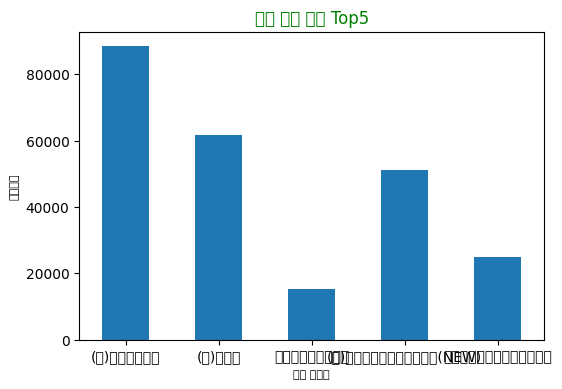

In [19]:
plt.rcParams['font.family'] = 'malgun gothic'
plt.figure(figsize = (6,4))
plt.ylabel("스크린수",fontsize=8)
boxoffice_rank.스크린수[:].plot(kind='bar', rot=0)
plt.title("흥행 영화 순위 Top5", color = 'green')
plt.xlabel("영화 배급사", fontsize=8)
plt.show()

findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


...

findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


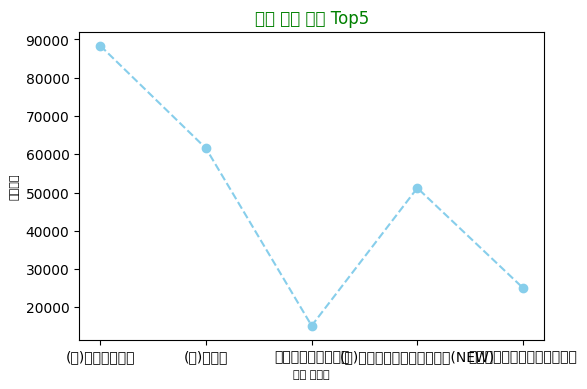

In [20]:
plt.figure(figsize=(6,4))
plt.plot(boxoffice_rank.스크린수[:], color ="skyblue", marker="o", linestyle="--")
plt.ylabel("스크린수",fontsize=8)
plt.title("흥행 영화 순위 Top5", color = 'green')
plt.xlabel("영화 배급사", fontsize=8)
plt.show()

In [21]:
df = pd.read_csv("./data/it_product.csv", encoding="utf-8")
df['price'].describe()

count         7.000000
mean     191142.857143
std      279331.003513
min       22000.000000
25%       26000.000000
50%       29000.000000
75%      317500.000000
max      600000.000000
Name: price, dtype: float64

In [22]:
df.describe(include="all")

,product,price,year
count,7,7.000000,7.000000
unique,3,NaN,NaN
top,usb,NaN,NaN
freq,3,NaN,NaN
mean,NaN,191142.857143,2022.142857
std,NaN,279331.003513,0.690066
min,NaN,22000.000000,2021.000000
25%,NaN,26000.000000,2022.000000
50%,NaN,29000.000000,2022.000000
75%,NaN,317500.000000,2022.500000


In [23]:
df.count()

product    7
price      7
year       7
dtype: int64

In [24]:
df['price'].std()

np.float64(279331.0035134115)

In [25]:
df['price'].median()

np.float64(29000.0)

In [26]:
df2 = df.groupby(['product']).sum()
df2 = df2.sort_values(by="price", ascending=True)

In [27]:
df2.drop(['year'], axis=1, inplace=True)
df2

,price
product,
mouse,49000
usb,89000
iPad,1200000


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


...

findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


findfont: Font family 'malgun gothic' not found.


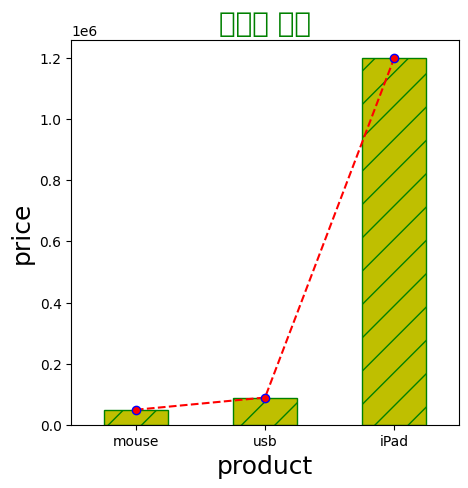

In [28]:
plt.figure(figsize=(5,5))
plt.xlabel("제품명", fontsize=18)
plt.ylabel("price", fontsize=18)
plt.title("제품별 총액", fontsize=20, color = "green")
df2.price[:].plot(kind='bar', hatch="/",color = "y", edgecolor="green", rot=0)
df2.price[:].plot(kind='line', linestyle="--", marker="o", markeredgecolor = "blue", color = "r")
plt.show()